# Topic 2: Predictive Modelling - Mode Choice Prediction

This notebook follows the same modelling flow as the original `Daan_Topic2.ipynb`: inspect the data, preprocess, select features with permutation importance, compare baselines, tune XGBoost, evaluate on a grouped test set, interpret with SHAP, and export the final model for Topic 3.

The main difference is that the preprocessing is a bit safer: categorical code variables are one-hot encoded, missing values are imputed instead of dropping all incomplete rows, ODiN trip weights are used, and Topic 1 access variables are merged in from the combined dataset.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 120)

In [2]:
# Repository structure
ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR.parents[1] / 'data'
OUTPUTS_DIR = ROOT_DIR / 'outputs'
DASHBOARD_DATA_DIR = ROOT_DIR / 'dashboard' / 'data'
DASHBOARD_DATA_DIR.mkdir(parents=True, exist_ok=True)

ODIN_PATH = DATA_DIR / 'ODiN2024 Updated with Header' / 'ODiN2024_DANS_Databestand_ Updated.xlsx'
PC6HNR_PATH = DATA_DIR / 'pc6hnr20250801_gwb.csv'
VOORZIENINGEN_PATH = DATA_DIR / 'voorzieningen_per_buurt_klasse.csv'
BUURT_MASTER_PATH = OUTPUTS_DIR / 'buurt_master.csv'
DASHBOARD_NEIGHBORHOOD_PATH = DASHBOARD_DATA_DIR / 'neighborhood_data.csv'

MODEL_PATH = DASHBOARD_DATA_DIR / 'xgb_mode_choice_pipeline.pkl'
METADATA_PATH = DASHBOARD_DATA_DIR / 'mode_choice_metadata.json'
EVALUATION_PATH = DASHBOARD_DATA_DIR / 'mode_choice_evaluation.json'

print(f'Data folder: {DATA_DIR}')
print(f'ODiN file exists: {ODIN_PATH.exists()}')


Data folder: c:\Users\daanr\OneDrive - TU Eindhoven\School\1BM130\data
ODiN file exists: True


## Data Loading

The target is `KHvm`, the ODiN six-class main transport mode category. We exclude class 7 (`Overig`) because it is heterogeneous and less useful for policy simulation.

Important leakage note: `Hvm` is not used as a predictor because it is the detailed mode variable from which `KHvm` is derived.

In [3]:
odin_columns = [
    'OPID', 'KHvm', 'Verpl', 'AfstV', 'KVertTijd', 'Weekdag', 'Maand',
    'VertLoc', 'VertPC_PRAM', 'Doel', 'KLeeft', 'Geslacht',
    'Opleiding_DANS24', 'BetWerk', 'MaatsPart_DANS24', 'OPRijbewijsAu',
    'HHGestInkG', 'HHPers_DANS24', 'HHSam_DANS24', 'HHAuto_DANS24',
    'HHRijbewijsAu', 'OPAuto_DANS24', 'HHBrSn_DANS24', 'HHEFiets_DANS24',
    'OVStKaart', 'Sted', 'Prov', 'GemGr', 'Corop', 'FqLopen', 'FqNEFiets',
    'FqEFiets', 'FqBTM', 'FqTrein', 'FqAutoB', 'FqAutoP', 'FqBrSnor',
    'WrkVerg', 'VergOV', 'BrbWrk', 'BrbOnd', 'BrbSup', 'BrbZiek',
    'BrbArts', 'BrbStat', 'BrbHalte', 'BrbSport', 'FactorV'
]

# Set this to e.g. 50_000 while developing. Use None for final results.
SAMPLE_ROWS = None

odin = pd.read_excel(ODIN_PATH, usecols=odin_columns, nrows=SAMPLE_ROWS, decimal=',')
odin.replace('.', np.nan, inplace=True)
odin.head()

,OPID,HHPers_DANS24,HHSam_DANS24,Sted,GemGr,Prov,Corop,Geslacht,KLeeft,BetWerk,MaatsPart_DANS24,Opleiding_DANS24,HHGestInkG,HHRijbewijsAu,OPRijbewijsAu,HHAuto_DANS24,OPAuto_DANS24,HHBrSn_DANS24,HHEFiets_DANS24,FqLopen,FqNEFiets,FqEFiets,FqBTM,FqTrein,FqAutoB,FqAutoP,FqBrSnor,OVStKaart,WrkVerg,VergOV,BrbWrk,BrbOnd,BrbSup,BrbZiek,BrbArts,BrbStat,BrbHalte,BrbSport,Maand,Weekdag,Verpl,Doel,VertLoc,VertPC_PRAM,AfstV,KHvm,KVertTijd,FactorV
0,350000661958,2,2,3,5,5,40,1,16,0,5,3,6,2,1,1,1,0,0,1,1,5,5,5,2,3,5,4,3,2,4,4,1,1,1,1,5,1,8,6,1.0,9.0,1.0,8211.0,1300.0,1.0,7.0,20705.362492
1,350000661958,2,2,3,5,5,40,1,16,0,5,3,6,2,1,1,1,0,0,1,1,5,5,5,2,3,5,4,3,2,4,4,1,1,1,1,5,1,8,6,1.0,9.0,4.0,6721.0,700.0,1.0,9.0,20705.362492
2,350000661958,2,2,3,5,5,40,1,16,0,5,3,6,2,1,1,1,0,0,1,1,5,5,5,2,3,5,4,3,2,4,4,1,1,1,1,5,1,8,6,1.0,1.0,4.0,6846.0,1200.0,1.0,13.0,20705.362492
3,350000773958,2,2,5,4,6,16,2,8,3,2,3,10,2,1,2,1,0,0,3,5,5,5,5,1,3,5,0,1,2,3,5,3,3,1,3,2,5,7,2,1.0,2.0,1.0,6669.0,380.0,1.0,4.0,89049.971908
4,350000773958,2,2,5,4,6,16,2,8,3,2,3,10,2,1,2,1,0,0,3,5,5,5,5,1,3,5,0,1,2,3,5,3,3,1,3,2,5,7,2,1.0,1.0,3.0,3772.0,380.0,1.0,11.0,89049.971908


In [4]:
missing = odin.isnull().sum()
missing_pct = (missing / len(odin) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing count': missing,
    'Missing %': missing_pct,
    'Non-missing': odin.notnull().sum(),
    'Dtype': odin.dtypes,
}).sort_values('Missing %', ascending=False)
missing_summary.head(20)

,Missing count,Missing %,Non-missing,Dtype
AfstV,14815,6.94,198608,float64
KVertTijd,14815,6.94,198608,float64
VertPC_PRAM,13906,6.52,199517,float64
VertLoc,13906,6.52,199517,float64
Doel,13906,6.52,199517,float64
KHvm,13906,6.52,199517,float64
Verpl,13906,6.52,199517,float64
OPID,0,0.00,213423,int64
KLeeft,0,0.00,213423,int64
HHPers_DANS24,0,0.00,213423,int64


## Topic 1 Combined Access Dataset

This notebook builds the access features it needs directly from the available project files. If a dashboard-prepared neighborhood dataset already exists it can reuse that; otherwise it builds the required access variables from `buurt_master.csv` and `voorzieningen_per_buurt_klasse.csv`.

In [5]:
def to_buurt8(code):
    if pd.isna(code):
        return np.nan
    value = str(code).strip()
    if value.upper().startswith('BU'):
        value = value[2:]
    return value.zfill(8)


def amenity_to_numeric(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace('+', '')
    try:
        return float(text)
    except ValueError:
        return np.nan


amenity_cols = [
    'bike10_klasse_supermarkt', 'bike10_klasse_huisarts',
    'bike10_klasse_basisschool', 'bike10_klasse_ziekenhuis',
    'bike10_klasse_apotheek', 'bike10_klasse_bushalte',
    'bike10_klasse_treinstation', 'bike10_klasse_voortgezet_onderwijs'
]

if DASHBOARD_NEIGHBORHOOD_PATH.exists():
    access = pd.read_csv(DASHBOARD_NEIGHBORHOOD_PATH)
    print('Loaded dashboard neighborhood dataset')
else:
    print('Topic 1 combined dataset not found; building a lightweight fallback dataset')
    buurt = pd.read_csv(BUURT_MASTER_PATH)
    voorzieningen = pd.read_csv(VOORZIENINGEN_PATH)
    voorzieningen = voorzieningen.rename(columns={voorzieningen.columns[0]: 'buurtcode'})
    voorzieningen['buurt_key'] = voorzieningen['buurtcode'].apply(to_buurt8)
    voorzieningen = voorzieningen.rename(columns={c: f'bike10_{c}' for c in voorzieningen.columns if c.startswith('klasse_')})
    for col in amenity_cols:
        if col in voorzieningen.columns:
            voorzieningen[col] = voorzieningen[col].apply(amenity_to_numeric)
    access = buurt.merge(voorzieningen[['buurt_key'] + amenity_cols], left_on='gwb_code_8', right_on='buurt_key', how='left')
    for col in amenity_cols:
        if col not in access.columns:
            access[col] = np.nan
    weights = pd.Series({
        'bike10_klasse_supermarkt': 1.30,
        'bike10_klasse_huisarts': 1.20,
        'bike10_klasse_basisschool': 1.20,
        'bike10_klasse_apotheek': 1.10,
        'bike10_klasse_bushalte': 0.90,
        'bike10_klasse_treinstation': 0.80,
        'bike10_klasse_voortgezet_onderwijs': 0.90,
        'bike10_klasse_ziekenhuis': 0.60,
    })
    amenity_binary = access[amenity_cols].fillna(0).gt(0).astype(float)
    access['bike10_weighted_score'] = amenity_binary.mul(weights, axis=1).sum(axis=1) / weights.sum() * 100
    access['bike10_score'] = amenity_binary.mean(axis=1) * 100
    access['access_usage_gap'] = np.nan
    access['pattern_label'] = 'Unknown'
    access['buurt_key'] = access['gwb_code_8'].astype(str).str.zfill(8)

# Normalize common column names from Topic 1/dashboard variants
rename_candidates = {
    'buurtcode': 'buurt_key',
    'Buurt2025': 'buurt_key',
    'gwb_code_8': 'buurt_key',
    'bev_dich': 'bev_dich',
    'a_inw': 'a_inw',
}
for old, new in rename_candidates.items():
    if old in access.columns and new not in access.columns:
        access[new] = access[old]

access['buurt_key'] = access['buurt_key'].apply(to_buurt8)
for col in amenity_cols + ['bike10_weighted_score', 'bike10_score', 'access_usage_gap', 'bev_dich', 'a_inw']:
    if col not in access.columns:
        access[col] = np.nan
    access[col] = pd.to_numeric(access[col], errors='coerce')
if 'pattern_label' not in access.columns:
    access['pattern_label'] = 'Unknown'

access_features = access[[
    'buurt_key', 'bike10_weighted_score', 'bike10_score', 'access_usage_gap',
    'bev_dich', 'a_inw', 'pattern_label'
] + amenity_cols].drop_duplicates('buurt_key')

print(access_features.shape)
access_features.head()

Loaded dashboard neighborhood dataset
(10941, 15)


,buurt_key,bike10_weighted_score,bike10_score,access_usage_gap,bev_dich,a_inw,pattern_label,bike10_klasse_supermarkt,bike10_klasse_huisarts,bike10_klasse_basisschool,bike10_klasse_ziekenhuis,bike10_klasse_apotheek,bike10_klasse_bushalte,bike10_klasse_treinstation,bike10_klasse_voortgezet_onderwijs
0,00140000,57.5,50.0,14.7,12845.0,4765.0,Local living,2.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0
1,00140001,75.0,75.0,32.2,12855.0,7085.0,Local living,2.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0
2,00140002,52.5,50.0,9.7,16293.0,4370.0,Local living,0.0,1.0,2.0,0.0,0.0,2.0,0.0,2.0
3,00140003,27.5,25.0,-15.3,17475.0,1705.0,Local living,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,00140005,57.5,50.0,14.7,14976.0,6515.0,Local living,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0


## Link ODiN Origin PC4 to CBS Buurt

ODiN only gives a PRAM-modified 4-digit origin postcode. The PC6 crosswalk is used to assign each PC4 to the buurt with the most PC6 addresses. This is an approximation, but it lets the model use the Topic 1 neighborhood access variables.

In [6]:
pc4_cache = OUTPUTS_DIR / 'pc4_dominant_buurt.csv'

if pc4_cache.exists():
    pc4_to_buurt = pd.read_csv(pc4_cache, dtype={'pc4': 'string', 'buurt_key': 'string'})
    print('Loaded cached PC4-to-buurt mapping')
else:
    counts = {}
    for chunk in pd.read_csv(
        PC6HNR_PATH,
        sep=';',
        usecols=['PC6', 'Buurt2025'],
        dtype={'PC6': 'string', 'Buurt2025': 'string'},
        chunksize=1_000_000,
    ):
        chunk = chunk.dropna()
        chunk['pc4'] = chunk['PC6'].str[:4]
        chunk['buurt_key'] = chunk['Buurt2025'].apply(to_buurt8)
        grouped = chunk.groupby(['pc4', 'buurt_key'], observed=True).size()
        for key, value in grouped.items():
            counts[key] = counts.get(key, 0) + int(value)

    pc4_to_buurt = (
        pd.Series(counts)
        .rename('address_count')
        .reset_index()
        .rename(columns={'level_0': 'pc4', 'level_1': 'buurt_key'})
        .sort_values(['pc4', 'address_count'], ascending=[True, False])
        .drop_duplicates('pc4')
        [['pc4', 'buurt_key', 'address_count']]
    )
    pc4_to_buurt.to_csv(pc4_cache, index=False)
    print(f'Saved PC4-to-buurt mapping to {pc4_cache}')

pc4_to_buurt.head()

Saved PC4-to-buurt mapping to c:\Users\daanr\OneDrive - TU Eindhoven\School\1BM130\Github\1BM130\outputs\pc4_dominant_buurt.csv


,pc4,buurt_key,address_count
7,1011,0363AF08,674
20,1012,0363AE03,566
24,1013,0363AA02,1364
55,1014,0363EC01,2039
60,1015,0363AB05,1166


## Data Preprocessing

This section stays close to the original notebook: build `df`, define the target, make derived distance variables, merge the access data, and prepare `X`, `y`, groups, and weights.

In [7]:
df = odin.copy()

# Keep regular trips and the six interpretable KHvm classes
# KHvm: 1 car-driver, 2 car-passenger, 3 train, 4 BTM, 5 bike, 6 walking, 7 other
df = df[df['Verpl'] == 1].copy()
df = df[df['KHvm'].between(1, 6, inclusive='both')].copy()

class_labels = {
    0: 'Car-driver',
    1: 'Car-passenger',
    2: 'Train',
    3: 'Bus/tram/metro',
    4: 'Bike',
    5: 'Walking',
}
label_names = [class_labels[i] for i in sorted(class_labels)]

df['target'] = df['KHvm'].astype(int) - 1

# AfstV is in hectometers, so divide by 10 for km
df['dist_km'] = pd.to_numeric(df['AfstV'], errors='coerce') / 10
# log distance helps tree models handle the long right tail
# without removing long-distance trips.
df['log_dist_km'] = np.log1p(df['dist_km'].clip(lower=0))

df['pc4'] = pd.to_numeric(df['VertPC_PRAM'], errors='coerce').astype('Int64').astype('string').str.zfill(4)
df = df.merge(pc4_to_buurt[['pc4', 'buurt_key']], on='pc4', how='left')
df = df.merge(access_features, on='buurt_key', how='left')

# ODiN trip weight, used in final fitting and evaluation.
df['wV'] = pd.to_numeric(df['FactorV'], errors='coerce').fillna(0)
df['wV'] = df['wV'].where(df['wV'] > 0, 1)

print(df.shape)
df[['KHvm', 'target', 'dist_km', 'pc4', 'buurt_key', 'bike10_weighted_score']].head()

(172465, 68)


,KHvm,target,dist_km,pc4,buurt_key,bike10_weighted_score
0,1.0,0,130.0,8211,09950115,11.2
1,1.0,0,70.0,6721,02283004,26.2
2,1.0,0,120.0,6846,02022447,26.2
3,1.0,0,38.0,6669,17400200,57.5
4,1.0,0,38.0,3772,02035414,71.2


In [8]:
mode_counts = df['target'].map(class_labels).value_counts()
mode_shares = mode_counts / mode_counts.sum() * 100
weighted_mode_shares = df.groupby(df['target'].map(class_labels))['wV'].sum()
weighted_mode_shares = weighted_mode_shares / weighted_mode_shares.sum() * 100

pd.DataFrame({
    'count': mode_counts,
    'share_%': mode_shares.round(1),
    'weighted_share_%': weighted_mode_shares.round(1),
})

,count,share_%,weighted_share_%
target,,,
Bike,50098,29.0,28.7
Bus/tram/metro,4882,2.8,2.3
Car-driver,60953,35.3,34.5
Car-passenger,18441,10.7,11.2
Train,5350,3.1,2.6
Walking,32741,19.0,20.7


In [9]:
numeric_features = [
    'dist_km', 'log_dist_km',
    'bike10_weighted_score', 'bike10_score', 'access_usage_gap',
    'bev_dich', 'a_inw',
] + amenity_cols

categorical_features = [
    'KVertTijd', 'Weekdag', 'Maand', 'VertLoc', 'Doel', 'KLeeft',
    'Geslacht', 'Opleiding_DANS24', 'BetWerk', 'MaatsPart_DANS24',
    'OPRijbewijsAu', 'HHGestInkG', 'HHPers_DANS24', 'HHSam_DANS24',
    'HHAuto_DANS24', 'HHRijbewijsAu', 'OPAuto_DANS24', 'HHBrSn_DANS24',
    'HHEFiets_DANS24', 'OVStKaart', 'Sted', 'Prov', 'GemGr', 'Corop',
    'FqLopen', 'FqNEFiets', 'FqEFiets', 'FqBTM', 'FqTrein', 'FqAutoB',
    'FqAutoP', 'FqBrSnor', 'WrkVerg', 'VergOV', 'BrbWrk', 'BrbOnd',
    'BrbSup', 'BrbZiek', 'BrbArts', 'BrbStat', 'BrbHalte', 'BrbSport',
    'pattern_label', 'buurt_key'
]

feature_cols = numeric_features + categorical_features

for col in feature_cols:
    if col not in df.columns:
        df[col] = np.nan

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in categorical_features:
    df[col] = df[col].astype('string').fillna('missing')

X_full = df[feature_cols].copy()
y = df['target'].astype(int)
groups = df['OPID']
weights = df['wV']

X_full.head()

,dist_km,log_dist_km,bike10_weighted_score,bike10_score,access_usage_gap,bev_dich,a_inw,bike10_klasse_supermarkt,bike10_klasse_huisarts,bike10_klasse_basisschool,bike10_klasse_ziekenhuis,bike10_klasse_apotheek,bike10_klasse_bushalte,bike10_klasse_treinstation,bike10_klasse_voortgezet_onderwijs,KVertTijd,Weekdag,Maand,VertLoc,Doel,KLeeft,Geslacht,Opleiding_DANS24,BetWerk,MaatsPart_DANS24,OPRijbewijsAu,HHGestInkG,HHPers_DANS24,HHSam_DANS24,HHAuto_DANS24,HHRijbewijsAu,OPAuto_DANS24,HHBrSn_DANS24,HHEFiets_DANS24,OVStKaart,Sted,Prov,GemGr,Corop,FqLopen,FqNEFiets,FqEFiets,FqBTM,FqTrein,FqAutoB,FqAutoP,FqBrSnor,WrkVerg,VergOV,BrbWrk,BrbOnd,BrbSup,BrbZiek,BrbArts,BrbStat,BrbHalte,BrbSport,pattern_label,buurt_key
0,130.0,4.875197,11.2,12.5,-13.9,461.0,260.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,7.0,6,8,1.0,9.0,16,1,3,0,5,1,6,2,2,1,2,1,0,0,4,3,5,5,40,1,1,5,5,5,2,3,5,3,2,4,4,1,1,1,1,5,1,Policy opportunity,09950115
1,70.0,4.262680,26.2,25.0,-9.5,2208.0,4255.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,9.0,6,8,4.0,9.0,16,1,3,0,5,1,6,2,2,1,2,1,0,0,4,3,5,5,40,1,1,5,5,5,2,3,5,3,2,4,4,1,1,1,1,5,1,Local living,02283004
2,120.0,4.795791,26.2,25.0,-0.9,3421.0,6995.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,13.0,6,8,4.0,1.0,16,1,3,0,5,1,6,2,2,1,2,1,0,0,4,3,5,5,40,1,1,5,5,5,2,3,5,3,2,4,4,1,1,1,1,5,1,Local living,02022447
3,38.0,3.663562,57.5,50.0,35.0,1903.0,3535.0,1.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,4.0,2,7,1.0,2.0,8,2,3,3,2,1,10,2,2,2,2,1,0,0,0,5,6,4,16,3,5,5,5,5,1,3,5,1,2,3,5,3,3,1,3,2,5,Policy opportunity,17400200
4,38.0,3.663562,71.2,62.5,40.8,4217.0,5150.0,1.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,11.0,2,7,3.0,1.0,8,2,3,3,2,1,10,2,2,2,2,1,0,0,0,5,6,4,16,3,5,5,5,5,1,3,5,1,2,3,5,3,3,1,3,2,5,Local living,02035414


## Train-Test Split

A grouped split is used to avoid leakage between trips made by the same person.

In [10]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test = X_full.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
w_train = weights.iloc[train_idx].copy()
w_test = weights.iloc[test_idx].copy()

print(f'Train rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')
print(f'Group overlap: {len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))}')

Train rows: 146,544
Test rows: 25,921
Group overlap: 0


## Preprocessor

Tree models do not need scaling, but scaling the continuous variables is harmless and keeps the pipeline flexible. Categorical code variables are one-hot encoded, because many of these codes are labels rather than true numeric quantities.

In [11]:
def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=25)),
            ]), cat_cols),
        ]
    )


def make_model(model, num_cols=None, cat_cols=None):
    if num_cols is None:
        num_cols = numeric_features
    if cat_cols is None:
        cat_cols = categorical_features
    return Pipeline([
        ('preprocessor', make_preprocessor(num_cols, cat_cols)),
        ('classifier', model),
    ])

## RF/XGBoost Baselines

In [12]:
gkf5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    'Dummy baseline': Pipeline([
        ('classifier', DummyClassifier(strategy='most_frequent'))
    ]),
    'RF baseline': make_model(RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )),
    'XGBoost baseline': make_model(XGBClassifier(
        objective='multi:softprob',
        num_class=6,
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
    )),
}

baseline_results = []
for name, model in baseline_models.items():
    params = {}
    if name != 'Dummy baseline':
        params = {'classifier__sample_weight': w_train}
    cv = cross_validate(
        model,
        X_train,
        y_train,
        cv=gkf5,
        groups=groups_train,
        scoring=['accuracy', 'f1_macro'],
        n_jobs=-1,
        params=params,
    )
    baseline_results.append({
        'model': name,
        'accuracy': cv['test_accuracy'].mean(),
        'f1_macro': cv['test_f1_macro'].mean(),
        'f1_macro_std': cv['test_f1_macro'].std(),
    })

baseline_results = pd.DataFrame(baseline_results).sort_values('f1_macro', ascending=False)
baseline_results

,model,accuracy,f1_macro,f1_macro_std
2,XGBoost baseline,0.750798,0.694134,0.005279
1,RF baseline,0.707125,0.645334,0.005834
0,Dummy baseline,0.354767,0.087289,0.000003


## Feature Selection With Permutation Importance

This is close to the original notebook: fit a model on a sub-training split, calculate permutation importance on a validation split, then test how many top features to keep.

In [13]:
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
tr_idx, val_idx = next(gss_val.split(X_train, y_train, groups=groups_train))

X_tr = X_train.iloc[tr_idx]
y_tr = y_train.iloc[tr_idx]
w_tr = w_train.iloc[tr_idx]
X_val = X_train.iloc[val_idx]
y_val = y_train.iloc[val_idx]

# Permutation importance is slow, so cap the validation sample.
if len(X_val) > 6000:
    X_val_perm = X_val.sample(6000, random_state=42)
    y_val_perm = y_val.loc[X_val_perm.index]
else:
    X_val_perm = X_val
    y_val_perm = y_val

xgb_sel = XGBClassifier(
    objective='multi:softprob',
    num_class=6,
    n_estimators=250,
    max_depth=4,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

sel_pipe = make_model(xgb_sel)
sel_pipe.fit(X_tr, y_tr, classifier__sample_weight=w_tr)

perm = permutation_importance(
    sel_pipe,
    X_val_perm,
    y_val_perm,
    n_repeats=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
)

perm_imp = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)
perm_imp.head(30)

dist_km                       0.248075
FqTrein                       0.093374
FqAutoB                       0.082274
Doel                          0.078554
FqBTM                         0.072983
FqNEFiets                     0.050572
FqAutoP                       0.032893
FqEFiets                      0.032523
VergOV                        0.012498
bev_dich                      0.012241
log_dist_km                   0.007603
Geslacht                      0.006190
Weekdag                       0.005464
pattern_label                 0.004261
FqLopen                       0.003249
VertLoc                       0.002539
bike10_klasse_treinstation    0.001865
KVertTijd                     0.001630
OPRijbewijsAu                 0.001624
HHEFiets_DANS24               0.001608
BetWerk                       0.001280
BrbStat                       0.001240
GemGr                         0.001179
OVStKaart                     0.001155
HHSam_DANS24                  0.001047
BrbOnd                   

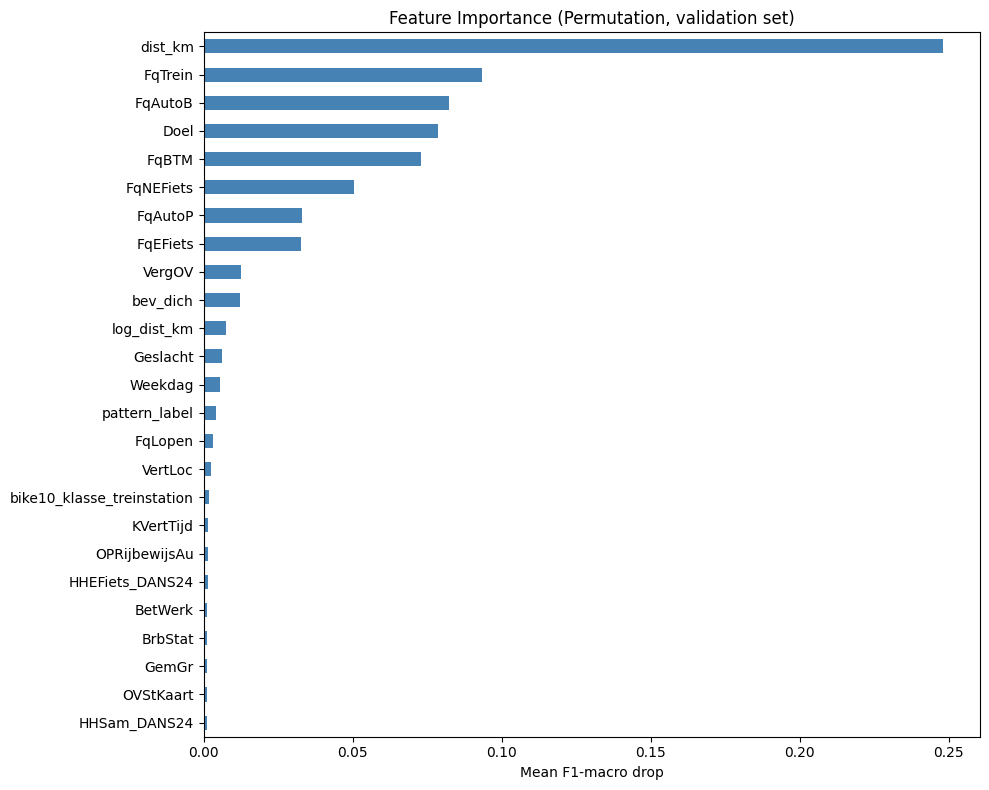

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
perm_imp.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (Permutation, validation set)')
ax.set_xlabel('Mean F1-macro drop')
plt.tight_layout()
plt.savefig('feature_importance_permutation_fixed.png', dpi=150)
plt.show()

In [15]:
# Similar to the original notebook: check how many top features are worth keeping.
top_k_results = []
for top_n in [15, 25, 35, 45, len(perm_imp)]:
    selected = perm_imp.head(top_n).index.tolist()
    selected_num = [c for c in selected if c in numeric_features]
    selected_cat = [c for c in selected if c in categorical_features]

    pipe = make_model(XGBClassifier(
        objective='multi:softprob',
        num_class=6,
        n_estimators=250,
        max_depth=4,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
    ), selected_num, selected_cat)

    cv = cross_validate(
        pipe,
        X_train[selected],
        y_train,
        cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42),
        groups=groups_train,
        scoring=['accuracy', 'f1_macro'],
        n_jobs=-1,
        params={'classifier__sample_weight': w_train},
    )
    top_k_results.append({
        'top_n': top_n,
        'accuracy': cv['test_accuracy'].mean(),
        'f1_macro': cv['test_f1_macro'].mean(),
    })

top_k_results = pd.DataFrame(top_k_results)
top_k_results

,top_n,accuracy,f1_macro
0,15,0.743046,0.683656
1,25,0.747216,0.687937
2,35,0.748144,0.689393
3,45,0.749167,0.689871
4,59,0.747769,0.686927


In [16]:
# Selecting top 45 by default. Change this after inspecting top_k_results if needed.
top_n = 45
selected_features = perm_imp.head(top_n).index.tolist()
selected_numeric = [c for c in selected_features if c in numeric_features]
selected_categorical = [c for c in selected_features if c in categorical_features]

X = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print(f'Selected {len(selected_features)} features')
selected_features

Selected 45 features


['dist_km',
 'FqTrein',
 'FqAutoB',
 'Doel',
 'FqBTM',
 'FqNEFiets',
 'FqAutoP',
 'FqEFiets',
 'VergOV',
 'bev_dich',
 'log_dist_km',
 'Geslacht',
 'Weekdag',
 'pattern_label',
 'FqLopen',
 'VertLoc',
 'bike10_klasse_treinstation',
 'KVertTijd',
 'OPRijbewijsAu',
 'HHEFiets_DANS24',
 'BetWerk',
 'BrbStat',
 'GemGr',
 'OVStKaart',
 'HHSam_DANS24',
 'BrbOnd',
 'BrbZiek',
 'HHPers_DANS24',
 'BrbSport',
 'OPAuto_DANS24',
 'WrkVerg',
 'access_usage_gap',
 'BrbArts',
 'HHGestInkG',
 'MaatsPart_DANS24',
 'BrbWrk',
 'HHRijbewijsAu',
 'a_inw',
 'HHAuto_DANS24',
 'Prov',
 'KLeeft',
 'FqBrSnor',
 'Maand',
 'bike10_klasse_bushalte',
 'bike10_klasse_supermarkt']

## Hyperparameter Tuning

Random search is kept from the original approach. It is computationally cheaper than grid search and good enough for this assignment.

In [17]:
xgb_param_dist = {
    'classifier__n_estimators': randint(250, 650),
    'classifier__max_depth': randint(3, 8),
    'classifier__learning_rate': uniform(0.02, 0.12),
    'classifier__subsample': uniform(0.70, 0.30),
    'classifier__colsample_bytree': uniform(0.65, 0.35),
    'classifier__min_child_weight': randint(1, 8),
    'classifier__gamma': uniform(0, 0.4),
}

xgb_pipe = make_model(XGBClassifier(
    objective='multi:softprob',
    num_class=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
), selected_numeric, selected_categorical)

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_param_dist,
    n_iter=35,
    scoring='f1_macro',
    cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

xgb_search.fit(X, y_train, groups=groups_train, classifier__sample_weight=w_train)

print('Best XGBoost params:', xgb_search.best_params_)
print(f'Best XGBoost f1_macro: {xgb_search.best_score_:.4f}')

Fitting 3 folds for each of 35 candidates, totalling 105 fits
Best XGBoost params: {'classifier__colsample_bytree': np.float64(0.9413549242801476), 'classifier__gamma': np.float64(0.08493564427131046), 'classifier__learning_rate': np.float64(0.04181899606485207), 'classifier__max_depth': 7, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 563, 'classifier__subsample': np.float64(0.8574269294896713)}
Best XGBoost f1_macro: 0.6997


## Training Best Model and Evaluating on Test Set

                precision    recall  f1-score   support

    Car-driver       0.77      0.87      0.82 799388165.3479103
 Car-passenger       0.69      0.48      0.57 271619134.9096464
         Train       0.77      0.71      0.74 64350255.7428135
Bus/tram/metro       0.71      0.50      0.59 61510728.88820009
          Bike       0.73      0.78      0.76 692393658.6055973
       Walking       0.83      0.76      0.79 505868655.1455539

      accuracy                           0.76 2395130598.6397214
     macro avg       0.75      0.68      0.71 2395130598.6397214
  weighted avg       0.76      0.76      0.76 2395130598.6397214

Weighted accuracy: 0.7630
Macro F1: 0.7107
Weighted F1: 0.7582


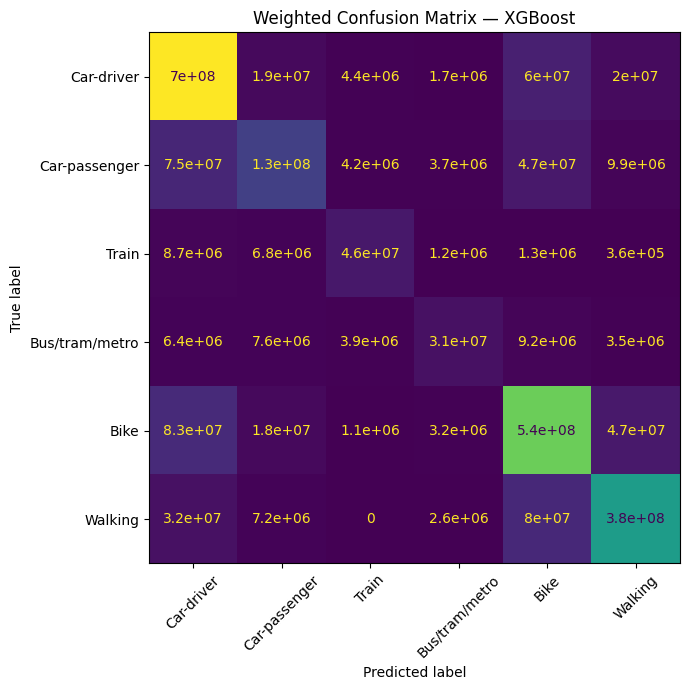

In [18]:
best_xgb = xgb_search.best_estimator_
best_xgb.fit(X, y_train, classifier__sample_weight=w_train)

y_pred = best_xgb.predict(X_test_selected)
report = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    sample_weight=w_test,
    output_dict=True,
    zero_division=0,
)

print(classification_report(y_test, y_pred, target_names=label_names, sample_weight=w_test, zero_division=0))
print(f"Weighted accuracy: {report['accuracy']:.4f}")
print(f"Macro F1: {report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1: {report['weighted avg']['f1-score']:.4f}")

cm = confusion_matrix(y_test, y_pred, sample_weight=w_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Weighted Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix_XGBoost_fixed.png', dpi=150)
plt.show()

## Model Evaluation: SHAP Values

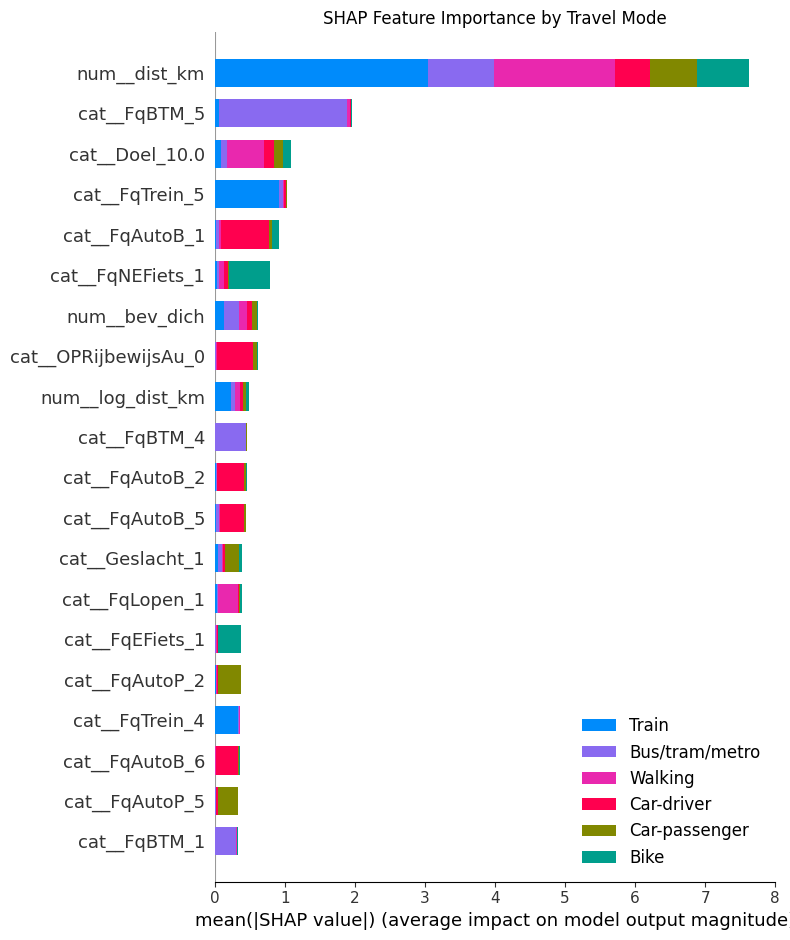

In [19]:
try:
    import shap

    X_shap = X_test_selected.sample(n=min(2500, len(X_test_selected)), random_state=42)
    X_shap_t = best_xgb.named_steps['preprocessor'].transform(X_shap)
    feat_names_clean = best_xgb.named_steps['preprocessor'].get_feature_names_out()

    explainer = shap.TreeExplainer(best_xgb.named_steps['classifier'])
    shap_vals = explainer.shap_values(X_shap_t)

    shap.summary_plot(
        shap_vals,
        X_shap_t,
        feature_names=feat_names_clean,
        class_names=label_names,
        plot_type='bar',
        show=False,
    )
    plt.gca().set_title('SHAP Feature Importance by Travel Mode')
    plt.tight_layout()
    plt.savefig('shap_summary_bar_fixed.png', dpi=150, bbox_inches='tight')
    plt.show()
except ModuleNotFoundError:
    print('SHAP is not installed. Install shap if this figure is needed for the report.')

## Export for Topic 3

The dashboard loads these files directly. This avoids rerunning the whole notebook just to start Topic 3.

In [20]:
joblib.dump(best_xgb, MODEL_PATH)

metadata = {
    'model_type': 'mode_choice_xgboost_notebook',
    'target': 'KHvm',
    'target_classes': class_labels,
    'feature_columns': selected_features,
    'numeric_features': selected_numeric,
    'categorical_features': selected_categorical,
    'dropped_target_codes': {'7': 'Overig'},
    'group_split': 'OPID',
    'best_params': xgb_search.best_params_,
    'notes': [
        'Generated from Topic2_ModeChoice_Fixed.ipynb',
        'Hvm is excluded to avoid target leakage.',
        'ODiN FactorV weights are used in final fit and evaluation.',
        'Topic 1 access variables are merged through origin PC4 -> dominant buurt.',
    ],
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

with EVALUATION_PATH.open('w', encoding='utf-8') as f:
    json.dump({
        'n_rows': int(len(X_full)),
        'n_train': int(len(X_train)),
        'n_test': int(len(X_test)),
        'accuracy': float(report['accuracy']),
        'macro_f1': float(report['macro avg']['f1-score']),
        'weighted_f1': float(report['weighted avg']['f1-score']),
        'classification_report': report,
        'confusion_matrix': cm.round(1).tolist(),
    }, f, indent=2)

print(f'Saved model to {MODEL_PATH}')
print(f'Saved metadata to {METADATA_PATH}')
print(f'Saved evaluation to {EVALUATION_PATH}')

Saved model to c:\Users\daanr\OneDrive - TU Eindhoven\School\1BM130\Github\1BM130\dashboard\data\xgb_mode_choice_pipeline.pkl
Saved metadata to c:\Users\daanr\OneDrive - TU Eindhoven\School\1BM130\Github\1BM130\dashboard\data\mode_choice_metadata.json
Saved evaluation to c:\Users\daanr\OneDrive - TU Eindhoven\School\1BM130\Github\1BM130\dashboard\data\mode_choice_evaluation.json
